## Task 1: Data Loading & Exploration

Step 1: Import all necessary libraries.

We import pandas for data manipulation, numpy for math, matplotlib for plotting, sklearn for the linear regression model and metrics, and openpyxl to read the Excel file.

In [11]:
# Step 1: Import all the libraries we need
# Think of libraries as toolboxes - each one gives us special powers

import pandas as pd                          # for working with data tables
import numpy as np                           # for math operations
import matplotlib.pyplot as plt              # for drawing charts
from sklearn.linear_model import LinearRegression   # the ML model
from sklearn.metrics import mean_squared_error      # to measure model accuracy
from openpyxl import load_workbook           # to read Excel files

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


Step 2: Load the dataset.

We use openpyxl to read the Excel file. Each row is parsed by splitting on commas (since the data is stored as a single CSV-like column in the Excel sheet). We extract the Month and Passengers columns and store them in a pandas DataFrame.

In [15]:
wb = load_workbook('dataset A1.xlsx', read_only=True)
ws = wb.active

rows = []

for row in ws.iter_rows(values_only=True):
    try:
        data = str(row[0]).replace('"', '').split(',')

        month = data[0]
        passengers = int(data[1])

        rows.append({
            "Month": month,
            "Passengers": passengers
        })

    except:
        continue   # skip any bad row

df = pd.DataFrame(rows)

print("Dataset loaded!")
print(len(df))

Dataset loaded!
144


Step 3: Convert 'Month' to datetime and set it as the index.

This allows us to work with the time series properly — date-based indexing, plotting, and future time-aware operations.

In [16]:
df['Month'] = pd.to_datetime(df['Month'])
df = df.set_index('Month')

print("Date conversion done!")
print(df.head(10))

Date conversion done!
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
1949-06-01         135
1949-07-01         148
1949-08-01         148
1949-09-01         136
1949-10-01         119


Step 4: Display basic statistics and the date range.

We see the dataset spans from January 1949 to December 1960, covering 144 months (12 years) of monthly airline passenger counts.

Observations:
1. The passenger count grows consistently over time — clear upward trend.
2. There is a seasonal pattern: peaks in summer months (July/August), dips in winter.
3. The variance (spread) also increases over time — this is called 'multiplicative seasonality'.

In [17]:
print("--- Basic Statistics ---")
print(df.describe())

print(df.index.min().date(), "to", df.index.max().date())
print("Total months:", len(df))

--- Basic Statistics ---
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000
1949-01-01 to 1960-12-01
Total months: 144


Step 5: Plot the time series.

The chart confirms all three observations: upward trend, repeating seasonal peaks, and increasing variance over time.

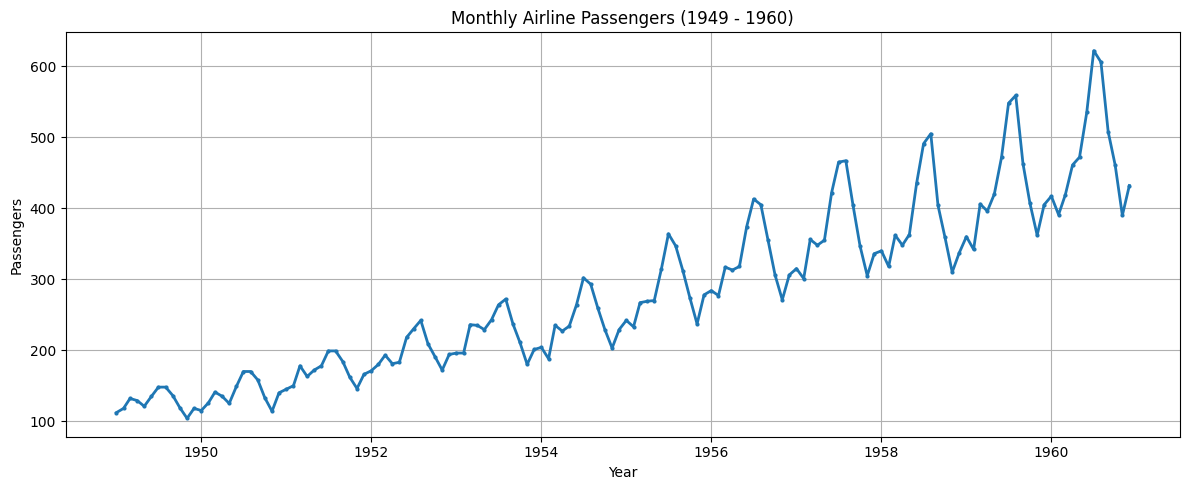

Chart saved


In [18]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df['Passengers'], linewidth=2, marker='o', markersize=2)

plt.title('Monthly Airline Passengers (1949 - 1960)')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.grid(True)

plt.tight_layout()
plt.savefig('time_series_plot.png')
plt.show()

print("Chart saved")

## Task 2: Convert Time Series to Supervised Learning Format

Step 1: Add a numeric time index 't'.

Linear regression needs numeric features. We create a sequential integer index 't' (1, 2, 3, ..., 144) representing each month's position in the series.

In [19]:
df['t'] = range(1, len(df) + 1)

print("Added time index")
print(df.head())

Added time index
            Passengers  t
Month                    
1949-01-01         112  1
1949-02-01         118  2
1949-03-01         132  3
1949-04-01         129  4
1949-05-01         121  5


Step 2: Add lag features.

- Passengers_lag1: passenger count from the previous month (1-month lag)
- Passengers_lag12: passenger count from the same month last year (12-month lag)

Lag features help capture autocorrelation (the tendency of a time series to be correlated with its own past values).

In [20]:
df['Passengers_lag1'] = df['Passengers'].shift(1)
df['Passengers_lag12'] = df['Passengers'].shift(12)

print("Added lag features")
print(df.head(15))

Added lag features
            Passengers   t  Passengers_lag1  Passengers_lag12
Month                                                        
1949-01-01         112   1              NaN               NaN
1949-02-01         118   2            112.0               NaN
1949-03-01         132   3            118.0               NaN
1949-04-01         129   4            132.0               NaN
1949-05-01         121   5            129.0               NaN
1949-06-01         135   6            121.0               NaN
1949-07-01         148   7            135.0               NaN
1949-08-01         148   8            148.0               NaN
1949-09-01         136   9            148.0               NaN
1949-10-01         119  10            136.0               NaN
1949-11-01         104  11            119.0               NaN
1949-12-01         118  12            104.0               NaN
1950-01-01         115  13            118.0             112.0
1950-02-01         126  14            115.0        

Step 3: Remove rows containing NaN.

The lag features introduce NaN values at the start of the series (there's no 'previous month' for month 1, and no 'same month last year' for the first 12 months). We drop these rows, leaving 132 usable rows.

In [23]:
df_clean = df.dropna()

print("NaN removed")
print(len(df), len(df_clean))

print(df_clean.head())

NaN removed
144 132
            Passengers   t  Passengers_lag1  Passengers_lag12
Month                                                        
1950-01-01         115  13            118.0             112.0
1950-02-01         126  14            115.0             118.0
1950-03-01         141  15            126.0             132.0
1950-04-01         135  16            141.0             129.0
1950-05-01         125  17            135.0             121.0


Step 4: Prepare X (features) and y (target).

X contains the three features: t, Passengers_lag1, Passengers_lag12
y contains the target: Passengers (the value we want to predict)

In [24]:
X = df_clean[['t', 'Passengers_lag1', 'Passengers_lag12']]
y = df_clean['Passengers']

print("X and y ready")
print(X.shape)
print(y.shape)

print(X.head(3))

X and y ready
(132, 3)
(132,)
             t  Passengers_lag1  Passengers_lag12
Month                                            
1950-01-01  13            118.0             112.0
1950-02-01  14            115.0             118.0
1950-03-01  15            126.0             132.0


## Task 3: Train/Test Split & Baseline Linear Regression

Step 1: Time-aware 80/20 train/test split.

For time series data, we NEVER shuffle. We take the first 80% of rows as training data and the last 20% as test data. This respects the temporal order of the data and prevents data leakage (using future information to predict the past).

Train size: 105 rows | Test size: 27 rows

In [25]:
split_index = int(len(df_clean) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train/Test done")
print(len(X_train), len(X_test))

Train/Test done
105 27


Step 2: Train baseline linear regression using only 't'.

The baseline model uses only the time index 't' as a feature. This is the simplest possible model — it just fits a straight line through the time series.

In [26]:
X_train_base = X_train[['t']]
X_test_base = X_test[['t']]

baseline_model = LinearRegression()
baseline_model.fit(X_train_base, y_train)

y_pred_base = baseline_model.predict(X_test_base)

print("Baseline model trained")
print(baseline_model.coef_[0], baseline_model.intercept_)

Baseline model trained
2.7066245075679034 81.05035938903865


Step 3: Evaluate the baseline model.

MSE (Mean Squared Error) = 5010.43, RMSE (Root MSE) = 70.78

The RMSE of ~71 passengers means the model is off by about 71 passengers on average. Looking at the chart, the baseline (straight line) misses the seasonal peaks and underestimates the later years significantly.

Baseline Results
5010.434892933773
70.78442549695359


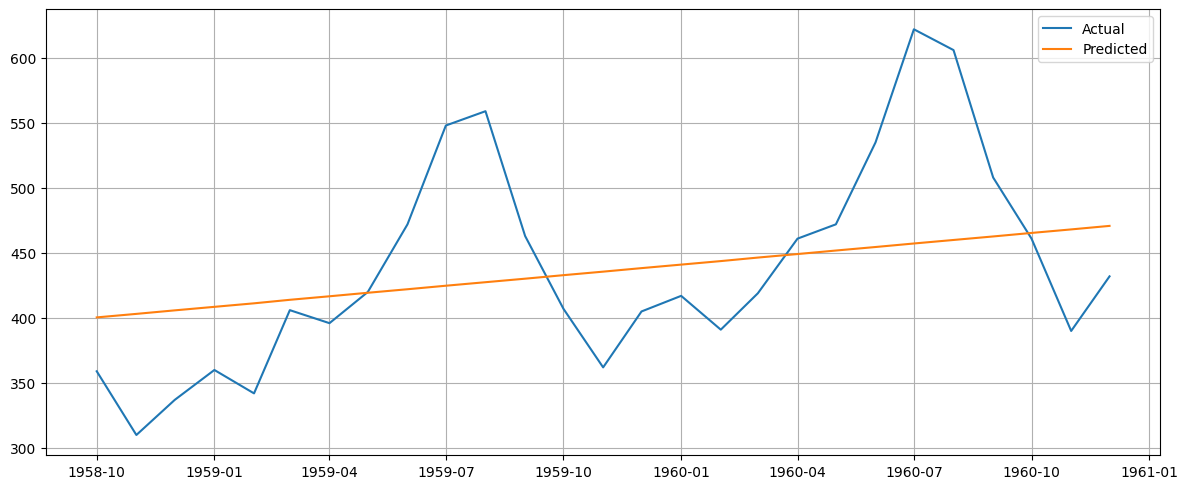

Chart saved


In [27]:
mse_base = mean_squared_error(y_test, y_pred_base)
rmse_base = np.sqrt(mse_base)

print("Baseline Results")
print(mse_base)
print(rmse_base)

plt.figure(figsize=(12, 5))

plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, y_pred_base, label='Predicted')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Chart saved")

## Task 4: Multiple Linear Regression with Lag Features

Step 1 & 2: Train and evaluate the multi-feature model.

Now we use all three features: t, Passengers_lag1, and Passengers_lag12. The lag features give the model memory of past values, allowing it to capture autocorrelation and seasonality.

Step 3: Comparison with baseline
- Baseline RMSE: ~70.78 (using only 't')
- Multi-feature RMSE: will be computed in the next cell

Expected: The multi-feature model should perform significantly better because lag features encode seasonal patterns that a straight-line trend cannot capture.

In [28]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred_multi = multi_model.predict(X_test)

print("Multi model trained")
print(multi_model.coef_)
print(multi_model.intercept_)

Multi model trained
[-0.05309516  0.19016691  0.88172876]
10.971108176317273


In [ ]:
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)

print("Multi-Feature Model Results")
print(f"MSE  : {mse_multi:.2f}")
print(f"RMSE : {rmse_multi:.2f}")
print()
print("--- Comparison ---")
print(f"Baseline RMSE  : {rmse_base:.2f}")
print(f"Multi-Feat RMSE: {rmse_multi:.2f}")
print(f"Improvement    : {rmse_base - rmse_multi:.2f} fewer passengers error on average")

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, y_pred_multi, label='Predicted (Multi-Feature)')
plt.legend()
plt.title('Multi-Feature Linear Regression vs Actual')
plt.grid(True)
plt.tight_layout()
plt.show()

## Reflections: Limitations of Linear Regression for Time Series

1. **Cannot capture multiplicative seasonality**: The passenger data has growing seasonal peaks. Linear regression assumes additive relationships, so it struggles with seasonality that grows proportionally with the trend.

2. **Stationarity assumption**: Linear regression works best on stationary data (constant mean and variance). This dataset is non-stationary — it has both trend and changing variance.

3. **Lag features help but are limited**: While lag features capture short-term patterns, linear regression cannot model the complex non-linear interactions in a time series.

4. **Better alternatives**: For this type of data, models like SARIMA (Seasonal ARIMA), Prophet, or LSTM neural networks would perform significantly better.